In [ ]:

#  ENVIRONMENT SETUP
 
from google.colab import drive
drive.mount('/content/drive')
import subprocess
subprocess.run(["unzip", "-uq", "/content/drive/My Drive/archive.zip",
                "-d", "/content"], check=True)
subprocess.run(["pip", "install", "sacremoses", "-q"], check=True)

Mounted at /content/drive


CompletedProcess(args=['pip', 'install', 'sacremoses', '-q'], returncode=0)

In [2]:
!pip install sacrebleu transformers torch timm radgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.0/588.0 kB 25.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 16.1 MB/s eta 0:00:00
  Created wheel for radgraph: filename=radgraph-0.1.18-py3-none-any.whl size=812635 sha256=8a953fea3c838fe88d59199c2934ca5f2ec899f2e74d295fda2259a1e8899830
  Stored in directory: /root/.cache/pip/wheels/fb/3c/fb/214f5d5cdab2a0f9f0904fd81d7fd1134404100b4444554df8
Successfully built radgraph


In [3]:
!unzip /content/drive/MyDrive/stage1_best_3.zip  -d /content


Archive:  /content/drive/MyDrive/stage1_best_3.zip
  inflating: /content/stage1_best_3.pt  


In [4]:
!unzip /content/drive/MyDrive/stage2_best_10.zip  -d /content


Archive:  /content/drive/MyDrive/stage2_best_10.zip
  inflating: /content/stage2_best_10.pt  


In [5]:

!unzip /content/drive/MyDrive/radioblip_ver6.zip  -d /content

Archive:  /content/drive/MyDrive/radioblip_ver6.zip
  inflating: /content/radioblip_ver6.py  


In [6]:
# !unzip /content/drive/MyDrive/checkpoints.zip  -d /content

# !unzip /content/drive/MyDrive/coderadio.zip  -d /content

In [7]:
%cd 'content'

[Errno 2] No such file or directory: 'content'
/content


In [ ]:
# INFERENCE & EVALUATION SCRIPT
# RadBLIPBioGPT — MIMIC-CXR Validation
#
# Metrics:
#    BLEU-1/2/3/4
#    RadGraph-F1
#    CheXBert vector similarity
#    RadCliQ
#
# Requirements:
#   pip install sacrebleu transformers torch timm radgraph
#   pip install git+https://github.com/stanfordmlgroup/CheXBert.git
 

import os
import ast
import re
import random
from collections import defaultdict

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# metrics
import sacrebleu
from transformers import AutoTokenizer, AutoModel
import numpy as np

# ── import model definition ──────────────────────────────
# Make sure radioblip_ver1.py is in the same directory
from radioblip_ver6 import (
    RadBLIPBioGPT,
    load_and_expand_dataframe,
    MIMICCXRDataset,
    collate_fn,
    PROMPT,
)

In [9]:
%cd '/content'

/content


In [10]:
!pip install nltk

In [11]:
import subprocess

def install(package):
    result = subprocess.run(
        ["pip", "install", "-q", package],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"Failed: {package}")
        print(result.stderr)
    else:
        print(f"✅ Installed: {package}")

install("sacrebleu==2.6.0")
install("bert-score")
install("radgraph")
install("numpy")



✅ Installed: sacrebleu==2.6.0
✅ Installed: bert-score
✅ Installed: radgraph
✅ Installed: numpy


In [12]:
import numpy as np
import sacrebleu

# verify versions
print(f"sacrebleu: {sacrebleu.__version__}")
print(f"numpy:     {np.__version__}")

# quick sanity check
metric = sacrebleu.BLEU(max_ngram_order=4, smooth_method="exp")
result = metric.corpus_score(["the cat sat on the mat"], [["the cat sat on the mat"]])
print(f"BLEU test: {result.score:.2f}  (should be 100.0) ✅")


sacrebleu: 2.6.0
numpy:     2.0.2
BLEU test: 100.00  (should be 100.0) ✅


In [13]:

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
VAL_CSV      = "mimic_cxr_aug_validate.csv"
ROOT_DIR     = "/content/official_data_iccv_final"
CKPT_PATH    = "stage2_best_10.pt"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE   = 4
MAX_LEN      = 256
NUM_WORKERS  = 4 if DEVICE == "cuda" else 0
NUM_SAMPLES  = 5          # number of sample reports to display
MAX_NEW_TOKENS = 150      # max tokens to generate per report
SAVE_RESULTS = "validation_results.csv"


In [14]:



# ─────────────────────────────────────────────────────────────
# VALIDATION DATASET  (no augmentation, no label masking)
# ─────────────────────────────────────────────────────────────
class MIMICCXRValDataset(Dataset):
    """
    Same as training dataset but:
      - no text augmentation concatenation
      - returns raw report string for metric computation
    """
    def __init__(
        self,
        df: pd.DataFrame,
        root_dir: str,
        tokenizer_name: str = "microsoft/biogpt",
        max_length: int = 256,
    ):
        self.df         = df.reset_index(drop=True)
        self.root_dir   = root_dir
        self.max_length = max_length
        self.tokenizer  = AutoTokenizer.from_pretrained(tokenizer_name)

        self.valid_indices = self._filter_valid_indices()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def _filter_valid_indices(self):
        valid = []
        for i, row in self.df.iterrows():
            all_exist = all(
                os.path.exists(os.path.join(self.root_dir, p))
                for p in row["images"]
            )
            if all_exist:
                valid.append(i)
        print(f"[ValDataset] {len(valid)} / {len(self.df)} valid studies found.")
        return valid

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        row = self.df.iloc[self.valid_indices[idx]]

        # ── Images ──────────────────────────────────────────
        images = []
        for path in row["images"]:
            full_path = os.path.join(self.root_dir, path)
            img = Image.open(full_path).convert("RGB")
            images.append(self.transform(img))
        images = torch.stack(images)

        # ── Prompt only (no report) for generation ──────────
        prompt_enc = self.tokenizer(
            PROMPT,
            return_tensors="pt",
            add_special_tokens=False,
        )

        return {
            "images":         images,
            "input_ids":      prompt_enc["input_ids"].squeeze(0),
            "attention_mask": prompt_enc["attention_mask"].squeeze(0),
            "report":         row["report"],          # ground truth string
            "study_id":       str(row["study_id"]),
        }


def val_collate_fn(batch):
    """Collate for validation — pads images, keeps reports as list."""
    max_imgs = max(item["images"].shape[0] for item in batch)

    padded_images, image_masks = [], []
    for item in batch:
        imgs = item["images"]
        n    = imgs.shape[0]
        pad  = torch.zeros(max_imgs - n, *imgs.shape[1:])
        padded_images.append(torch.cat([imgs, pad], dim=0))
        image_masks.append(
            torch.cat([torch.ones(n), torch.zeros(max_imgs - n)])
        )

    # pad input_ids to same length across batch
    max_len  = max(item["input_ids"].shape[0] for item in batch)
    input_ids_padded, attn_mask_padded = [], []
    for item in batch:
        ids  = item["input_ids"]
        mask = item["attention_mask"]
        pad_len = max_len - ids.shape[0]
        input_ids_padded.append(
            torch.cat([ids, torch.zeros(pad_len, dtype=ids.dtype)])
        )
        attn_mask_padded.append(
            torch.cat([mask, torch.zeros(pad_len, dtype=mask.dtype)])
        )

    return {
        "images":         torch.stack(padded_images),
        "image_mask":     torch.stack(image_masks),
        "input_ids":      torch.stack(input_ids_padded),
        "attention_mask": torch.stack(attn_mask_padded),
        "reports":        [item["report"]   for item in batch],
        "study_ids":      [item["study_id"] for item in batch],
    }


# ─────────────────────────────────────────────────────────────
# GENERATION  (inference forward pass)
# ─────────────────────────────────────────────────────────────
@torch.no_grad()
def generate_reports(model, batch, tokenizer, device, max_new_tokens=150):
    """
    Run the vision + Q-Former stack, then autoregressively
    generate text with BioGPT.
    """
    model.eval()

    images         = batch["images"].to(device)
    image_mask     = batch["image_mask"].to(device)
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    B              = images.shape[0]

    with torch.amp.autocast("cuda"):

        # ── 1. Vision encoder ─────────────────────────────────
        N, C, H, W = images.shape[1], images.shape[2], images.shape[3], images.shape[4]
        image_embeds = model.vision_encoder(images.view(B * N, C, H, W))
        image_embeds = model.vision_proj(image_embeds)
        T, D = image_embeds.shape[1], image_embeds.shape[2]
        image_embeds = image_embeds.view(B, N, T, D)

        # ── 2. Fuse valid images ───────────────────────────────
        fused_tokens = []
        for i in range(B):
            valid = image_embeds[i][image_mask[i].bool()]
            fused_tokens.append(valid.reshape(-1, D))

        max_tokens = max(t.shape[0] for t in fused_tokens)
        padded_visuals, visual_att_mask = [], []
        for t in fused_tokens:
            pad_len = max_tokens - t.shape[0]
            padded  = torch.cat([
                t,
                torch.zeros(pad_len, D, device=t.device, dtype=t.dtype)
            ], dim=0)
            mask = torch.cat([
                torch.ones(t.shape[0],  device=t.device),
                torch.zeros(pad_len,    device=t.device),
            ])
            padded_visuals.append(padded)
            visual_att_mask.append(mask)

        image_embeds    = torch.stack(padded_visuals)
        visual_att_mask = torch.stack(visual_att_mask)

        # ── 3. Q-Former ───────────────────────────────────────
        query_tokens = model.qformer.query_tokens.expand(B, -1, -1)
        q_out = model.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=visual_att_mask,
            return_dict=True,
        )
        visual_tokens = model.proj(q_out.last_hidden_state)  # [B, Q, llm_h]

        # ── 4. Build prompt embeddings ────────────────────────
        text_embeds = model.llm.get_input_embeddings()(input_ids)
        inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)

        vis_prefix_mask = torch.ones(
            B, visual_tokens.size(1),
            device=attention_mask.device, dtype=attention_mask.dtype,
        )
        full_attention_mask = torch.cat([vis_prefix_mask, attention_mask], dim=1)

        # ── 5. Generate ───────────────────────────────────────
        generated = model.llm.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attention_mask,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
        )

    # decode generated tokens
    decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)

    # strip the prompt prefix if present in output
    cleaned = []
    for text in decoded:
        if PROMPT.strip() in text:
            text = text[text.index(PROMPT.strip()) + len(PROMPT.strip()):].strip()
        cleaned.append(text.strip())

    return cleaned

In [34]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b07762655cf1082d44b31555d7e1d380b9907aacec3c855e901d17cd820884a2
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:


# ─────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────
import os
import random
import numpy as np
import sacrebleu
import pandas as pd


# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────

# ── 1. BLEU ───────────────────────────────────────────────────
def compute_bleu(hypotheses: list[str], references: list[str]) -> dict:
    """
    Compute BLEU-1/2/3/4 using sacrebleu 2.x.
    Returns scores on 0-100 scale.
    """
    assert len(hypotheses) == len(references), \
        f"Length mismatch: {len(hypotheses)} hypotheses vs {len(references)} references"

    if not hypotheses:
        return {f"BLEU-{n}": None for n in [1, 2, 3, 4]}

    scores = {}
    for n in [1, 2, 3, 4]:
        try:
            metric = sacrebleu.BLEU(max_ngram_order=n, smooth_method="exp")
            result = metric.corpus_score(hypotheses, [references])
            scores[f"BLEU-{n}"] = round(result.score, 4)
        except Exception as e:
            print(f"[Warning] BLEU-{n} failed: {e}")
            scores[f"BLEU-{n}"] = None

    return scores
 
# ── 2. ROUGE ──────────────────────────────────────────────────
def compute_rouge(hypotheses: list[str], references: list[str]) -> dict:
    """
    Compute ROUGE-1, ROUGE-2, ROUGE-L using rouge_score.
    Returns F1 scores on 0-1 scale.

    Args:
        hypotheses : list of generated reports
        references : list of ground truth reports

    Returns:
        dict with ROUGE-1, ROUGE-2, ROUGE-L F1 scores
    """
    try:
        from rouge_score import rouge_scorer as rs_module
    except ImportError:
        print("❌ rouge-score not installed — run: pip install rouge-score")
        return {"ROUGE-1": None, "ROUGE-2": None, "ROUGE-L": None}

    if not hypotheses:
        return {"ROUGE-1": None, "ROUGE-2": None, "ROUGE-L": None}

    scorer = rs_module.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    r1_scores, r2_scores, rl_scores = [], [], []
    failed = 0

    for hyp, ref in zip(hypotheses, references):
        try:
            # handle empty strings gracefully
            h = hyp.strip() if hyp and hyp.strip() else "normal"
            r = ref.strip() if ref and ref.strip() else "normal"
            result = scorer.score(r, h)
            r1_scores.append(result["rouge1"].fmeasure)
            r2_scores.append(result["rouge2"].fmeasure)
            rl_scores.append(result["rougeL"].fmeasure)
        except Exception as e:
            failed += 1
            if failed <= 3:
                print(f"  [ROUGE] Sample error: {e}")
            r1_scores.append(0.0)
            r2_scores.append(0.0)
            rl_scores.append(0.0)

    if failed > 0:
        print(f"[Warning] ROUGE: {failed}/{len(hypotheses)} samples failed.")

    return {
        "ROUGE-1": round(float(np.mean(r1_scores)), 4),
        "ROUGE-2": round(float(np.mean(r2_scores)), 4),
        "ROUGE-L": round(float(np.mean(rl_scores)), 4),
    }


# ── 3. RadGraph-F1 ────────────────────────────────────────────
def compute_radgraph_f1(hypotheses, references):
    try:
        from transformers import BertTokenizer

        # patch ALL missing methods that old AllenNLP calls
        if not hasattr(BertTokenizer, "encode_plus"):
            def _encode_plus(self, *args, **kwargs):
                kwargs.pop("return_special_tokens_mask", None)
                return self(*args, **kwargs)
            BertTokenizer.encode_plus = _encode_plus

        if not hasattr(BertTokenizer, "build_inputs_with_special_tokens"):
            def _build_inputs(self, token_ids_0, token_ids_1=None):
                if token_ids_1 is None:
                    return [self.cls_token_id] + token_ids_0 + [self.sep_token_id]
                return [self.cls_token_id] + token_ids_0 + [self.sep_token_id] + token_ids_1 + [self.sep_token_id]
            BertTokenizer.build_inputs_with_special_tokens = _build_inputs

        from radgraph import F1RadGraph
        f1_radgraph = F1RadGraph(reward_level="partial")

        scores = []
        failed = 0
        for hyp, ref in zip(hypotheses, references):
            try:
                score, _, _, _ = f1_radgraph(refs=[ref], hyps=[hyp])
                scores.append(float(score))
            except Exception as e:
                failed += 1
                if failed <= 3:
                    print(f"  Sample error: {e}")
                scores.append(0.0)

        if failed > 0:
            print(f"[Warning] RadGraph-F1: {failed}/{len(hypotheses)} samples failed.")

        return {"RadGraph-F1": round(float(np.mean(scores)), 4)}

    except Exception as e:
        print(f"[Warning] RadGraph-F1 setup failed: {e}")
        return {"RadGraph-F1": None}


# ── 4. BERTScore ──────────────────────────────────────────────
def compute_bertscore(hypotheses, references, device="cuda"):
    try:
        from bert_score import score as bert_score_fn
    except ImportError:
        print("❌ bert_score not installed — run: pip install bert-score")
        return {"BERTScore-P": None, "BERTScore-R": None, "BERTScore-F1": None}

    safe_hyps = [h if h.strip() else "normal" for h in hypotheses]
    safe_refs = [r if r.strip() else "normal" for r in references]

    candidate_models = [
        "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
        "allenai/scibert_scivocab_uncased",
        "bert-base-uncased",
    ]

    for model_name in candidate_models:
        try:
            print(f"[BERTScore] Trying model: {model_name}")
            P, R, F = bert_score_fn(
                safe_hyps, safe_refs,
                model_type=model_name,
                lang="en",
                device=device,
                verbose=False,
                batch_size=16,
            )
            return {
                "BERTScore-P":  round(P.mean().item(), 4),
                "BERTScore-R":  round(R.mean().item(), 4),
                "BERTScore-F1": round(F.mean().item(), 4),
            }
        except Exception as e:
            print(f"  ❌ {model_name} failed: {e}")
            continue

    print("❌ All BERTScore models failed.")
    return {"BERTScore-P": None, "BERTScore-R": None, "BERTScore-F1": None}


# ── 5. CheXbert ───────────────────────────────────────────────
def compute_chexbert_score(hypotheses: list[str], references: list[str]) -> dict:
    try:
        from CheXbert.src.models.bert_labeler import BertLabeler
        from CheXbert.src.bert_tokenizer import tokenize
        import torch
        from transformers import AutoTokenizer

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model  = BertLabeler()
        ckpt_path = "chexbert.pth"
        if not os.path.exists(ckpt_path):
            import urllib.request
            print("[CheXbert] Downloading weights …")
            urllib.request.urlretrieve(
                "https://stanfordmedicine.app.box.com/shared/static/"
                "c3stck6w6dol3h36grdc97xoydzxd7w9.pth",
                ckpt_path,
            )
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state)
        model.to(device)
        model.eval()

        def _label(texts):
            tokenizer  = AutoTokenizer.from_pretrained("bert-base-uncased")
            all_labels = []
            with torch.no_grad():
                for text in texts:
                    tokens = tokenize(tokenizer, [text])
                    tokens = {k: v.to(device) for k, v in tokens.items()}
                    out    = model(tokens)
                    preds  = [1 if logits.argmax(dim=-1).item() in (1, 3) else 0
                               for logits in out]
                    all_labels.append(preds)
            return np.array(all_labels, dtype=np.int8)

        hyp_labels = _label(hypotheses)
        ref_labels = _label(references)

    except Exception as e:
        print(f"[Warning] CheXbert model failed ({e}), falling back to rule-based labelling.")
        hyp_labels, ref_labels = _chexbert_rule_labels(hypotheses, references)

    return _chexbert_f1(hyp_labels, ref_labels)


def _chexbert_rule_labels(hypotheses, references):
    CONDITIONS_KEYWORDS = {
        "Enlarged Cardiomediastinum": ["enlarged cardiomediastinum", "mediastinal widening"],
        "Cardiomegaly":               ["cardiomegaly", "enlarged heart", "cardiac enlargement"],
        "Lung Opacity":               ["opacity", "opacification", "haziness"],
        "Lung Lesion":                ["lesion", "nodule", "mass", "lung lesion"],
        "Edema":                      ["edema", "oedema", "pulmonary edema", "vascular congestion"],
        "Consolidation":              ["consolidation", "lobar consolidation"],
        "Pneumonia":                  ["pneumonia", "infectious"],
        "Atelectasis":                ["atelectasis", "collapse", "subsegmental atelectasis"],
        "Pneumothorax":               ["pneumothorax"],
        "Pleural Effusion":           ["pleural effusion", "effusion"],
        "Pleural Other":              ["pleural thickening", "pleural other", "loculated"],
        "Fracture":                   ["fracture", "rib fracture"],
        "Support Devices":            ["catheter", "pacemaker", "tube", "support device", "leads"],
        "No Finding":                 ["no acute", "no findings", "unremarkable", "normal"],
    }
    def _label_one(text):
        t = text.lower()
        return [1 if any(kw in t for kw in kws) else 0
                for kws in CONDITIONS_KEYWORDS.values()]
    return (
        np.array([_label_one(h) for h in hypotheses], dtype=np.int8),
        np.array([_label_one(r) for r in references], dtype=np.int8),
    )


def _chexbert_f1(hyp_labels, ref_labels):
    from sklearn.metrics import f1_score
    micro_f1 = f1_score(
        ref_labels.flatten(), hyp_labels.flatten(),
        average="binary", zero_division=0,
    )
    per_condition_f1 = []
    for col in range(ref_labels.shape[1]):
        rc, hc = ref_labels[:, col], hyp_labels[:, col]
        if rc.sum() == 0 and hc.sum() == 0:
            continue
        per_condition_f1.append(f1_score(rc, hc, average="binary", zero_division=0))
    macro_f1 = float(np.mean(per_condition_f1)) if per_condition_f1 else 0.0
    return {
        "CheXbert-Micro-F1": round(micro_f1, 4),
        "CheXbert-Macro-F1": round(macro_f1, 4),
    }


# ── 6. RadCliQ ────────────────────────────────────────────────
def compute_radcliq(
    hypotheses: list[str],
    references: list[str],
    device: str = "cuda",
    # pass pre-computed sub-metrics to avoid re-computing them
    bleu_scores:      dict | None = None,
    bertscore_scores: dict | None = None,
    chexbert_scores:  dict | None = None,
) -> dict:
    """
    Compute RadCliQ-v0 composite metric (Yu et al., 2022).
    RadCliQ-v0 = -0.1974 * BLEU-4_norm + 0.5957 * BERTScore-F1 + 0.4499 * CheXbert-Micro-F1

    If sub-metric dicts are passed in (from a prior compute_metrics call),
    they are reused directly — no redundant re-computation.
    """
    try:
        from radcliq import RadCliq
        scorer = RadCliq(device=device)
        scores, failed = [], 0
        for hyp, ref in zip(hypotheses, references):
            try:
                score = scorer.compute([hyp], [ref])
                scores.append(float(score))
            except Exception as e:
                failed += 1
                if failed <= 3:
                    print(f"  Sample error: {e}")
                scores.append(0.0)
        if failed:
            print(f"[Warning] RadCliQ: {failed}/{len(hypotheses)} samples failed.")
        return {"RadCliQ-v0": round(float(np.mean(scores)), 4)}

    except (ImportError, Exception) as e:
        print(f"[Warning] RadCliQ package unavailable ({e}), using manual composite.")

    # ── Manual composite fallback ─────────────────────────────
    try:
        b  = bleu_scores      or compute_bleu(hypotheses, references)
        bs = bertscore_scores or compute_bertscore(hypotheses, references, device)
        cx = chexbert_scores  or compute_chexbert_score(hypotheses, references)

        bleu4_norm  = (b.get("BLEU-4")            or 0.0) / 100.0
        bscore_f1   =  bs.get("BERTScore-F1")     or 0.0
        chexbert_f1 =  cx.get("CheXbert-Micro-F1")or 0.0

        radcliq_v0 = -0.1974 * bleu4_norm + 0.5957 * bscore_f1 + 0.4499 * chexbert_f1
        return {"RadCliQ-v0": round(float(radcliq_v0), 4)}

    except Exception as e:
        print(f"[Warning] RadCliQ fallback failed: {e}")
        return {"RadCliQ-v0": None}
 
# COMPUTE ALL METRICS
 
def compute_metrics(
    results_df=None,
    load_path="generated_reports.csv",
    device="cuda",
    num_display_samples=5,
    model_label="RadBLIPBioGPT",       # label printed in the summary table header
):
    """
    Computes all metrics from a DataFrame or saved CSV.

    Pass results_df directly OR load from load_path.
    Re-run as many times as needed without re-running inference.

    Metrics computed:
        BLEU-1/2/3/4  · ROUGE-1/2/L  · RadGraph-F1
        BERTScore-P/R/F1  · CheXbert-Micro/Macro-F1  · RadCliQ-v0
    """
    if results_df is None:
        print(f"[Metrics] Loading results from {load_path} …")
        results_df = pd.read_csv(load_path)

    all_hypotheses = results_df["generated"].tolist()
    all_references = results_df["reference"].tolist()
    all_study_ids  = results_df["study_id"].tolist()

    print(f"[Metrics] Evaluating {len(all_hypotheses)} reports for [{model_label}] …")

    print("\n[Metrics] Computing BLEU …")
    bleu = compute_bleu(all_hypotheses, all_references)
    print(f"  {bleu}")

    print("[Metrics] Computing ROUGE …")
    rouge = compute_rouge(all_hypotheses, all_references)
    print(f"  {rouge}")

    print("[Metrics] Computing RadGraph-F1 …")
    radgraph = compute_radgraph_f1(all_hypotheses, all_references)
    print(f"  {radgraph}")

    print("[Metrics] Computing BERTScore …")
    bertscore = compute_bertscore(all_hypotheses, all_references, device)
    print(f"  {bertscore}")

    print("[Metrics] Computing CheXbert …")
    chexbert = compute_chexbert_score(all_hypotheses, all_references)
    print(f"  {chexbert}")

    print("[Metrics] Computing RadCliQ …")
    # pass pre-computed dicts so RadCliQ fallback doesn't recompute them
    radcliq = compute_radcliq(
        all_hypotheses, all_references, device,
        bleu_scores=bleu, bertscore_scores=bertscore, chexbert_scores=chexbert,
    )
    print(f"  {radcliq}")

    # ── Summary table ─────────────────────────────────────────
    all_metrics = {**bleu, **rouge, **radgraph, **bertscore, **chexbert, **radcliq}

    COL_W = 58
    print("\n" + "=" * COL_W)
    print(f"  VALIDATION RESULTS  —  {model_label}")
    print("=" * COL_W)
    sections = [
        ("Lexical",  ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4",
                      "ROUGE-1", "ROUGE-2", "ROUGE-L"]),
        ("Clinical", ["RadGraph-F1", "CheXbert-Micro-F1", "CheXbert-Macro-F1",
                      "RadCliQ-v0"]),
        ("Semantic", ["BERTScore-P", "BERTScore-R", "BERTScore-F1"]),
    ]
    for section_name, keys in sections:
        print(f"\n  ── {section_name} ──")
        for k in keys:
            v = all_metrics.get(k)
            status = f"{v:.4f}" if v is not None else "N/A"
            print(f"    {k:<22} {status}")
    print("\n" + "=" * COL_W)

    # ── Sample reports ────────────────────────────────────────
    print(f"\n[Samples] Showing {num_display_samples} generated reports:\n")
    sample_indices = random.sample(
        range(len(all_hypotheses)),
        min(num_display_samples, len(all_hypotheses)),
    )
    for rank, idx in enumerate(sample_indices, 1):
        print(f"{'─' * COL_W}")
        print(f"Sample {rank}  |  Study ID: {all_study_ids[idx]}")
        print(f"\n  REFERENCE:\n  {all_references[idx][:300]}...")
        print(f"\n  GENERATED:\n  {all_hypotheses[idx][:300]}...")
        print()

    return all_metrics


In [ ]:
# INFERENCE ONLY
 
def run_inference(
    model,
    val_loader,
    tokenizer,
    device,
    max_new_tokens=150,
    save_path="generated_reports.csv",
):
    """
    Runs inference on all validation images and saves
    hypotheses + references to CSV so they are never lost.
    """
    all_hypotheses = []
    all_references = []
    all_study_ids  = []

    print("\n[Inference] Generating reports …")
    for batch in tqdm(val_loader, desc="Generating"):
        generated = generate_reports(model, batch, tokenizer, device, max_new_tokens)
        all_hypotheses.extend(generated)
        all_references.extend(batch["reports"])
        all_study_ids.extend(batch["study_ids"])

    print(f"[Inference] Generated {len(all_hypotheses)} reports.")

    # ── Save immediately so nothing is lost ──────────────────
    results_df = pd.DataFrame({
        "study_id":  all_study_ids,
        "reference": all_references,
        "generated": all_hypotheses,
    })
    results_df.to_csv(save_path, index=False)
    print(f"[Saved] Generated reports → {save_path}")

    return results_df

In [ ]:
 
# ENTRY POINT
  
if __name__ == "__main__":

    # # # ── 1. Load validation data ───────────────────────────────
    # print("Loading validation dataframe …")
    # df_val = load_and_expand_dataframe(VAL_CSV)

    # print("Building validation dataset …")
    # val_dataset = MIMICCXRValDataset(
    #     df_val,
    #     root_dir=ROOT_DIR,
    #     max_length=MAX_LEN,
    # )

    # val_loader = DataLoader(
    #     val_dataset,
    #     batch_size=BATCH_SIZE,
    #     shuffle=False,
    #     collate_fn=val_collate_fn,
    #     num_workers=NUM_WORKERS,
    #     pin_memory=(DEVICE == "cuda"),
    # )


    # ── 2. Load model ─────────────────────────────────────────
    print("\nInitialising model architecture …")
    model = RadBLIPBioGPT().to(DEVICE)

    print(f"Loading checkpoint from {CKPT_PATH} …")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    print(f"  ↳ Loaded epoch {ckpt['epoch']}  |  train_loss={ckpt['loss']:.4f}")

    # ── 3. Tokenizer ──────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained("microsoft/biogpt")

    # # ── 4. Evaluate ───────────────────────────────────────────
    # # ── STEP 1: Run inference once (takes long time) ──────────────
    # results_df = run_inference(
    #     model, val_loader, tokenizer,
    #     device         = DEVICE,
    #     max_new_tokens = 150,
    #     save_path      = "generated_reports.csv",   # saved to disk immediately
    # )

    # # ── STEP 2: Compute metrics (fast, re-run anytime) ────────────
    # metrics = compute_metrics(
    #     results_df         = results_df,   # pass directly if already in memory
    #     device             = DEVICE,
    #     num_display_samples= 5,
    # )

    # ── If kernel crashes or metrics error — reload from CSV ──────
    metrics = compute_metrics(
        load_path          = "/content/generated_reports_raddino.csv",   # no need to re-run inference
        device             = DEVICE,
        num_display_samples= 5,
    )
    print("\nEvaluation complete.")


Initialising model architecture …


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

  ❌ allenai/scibert_scivocab_uncased failed: int too big to convert
[BERTScore] Trying model: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  {'BERTScore-P': 0.6097, 'BERTScore-R': 0.6396, 'BERTScore-F1': 0.6192}
[Metrics] Computing CheXbert …
[Warning] CheXbert model failed (No module named 'CheXbert'), falling back to rule-based labelling.
  {'CheXbert-Micro-F1': 0.5773, 'CheXbert-Macro-F1': 0.3381}
[Metrics] Computing RadCliQ …
[Warning] RadCliQ package unavailable (No module named 'radcliq'), using manual composite.
  {'RadCliQ-v0': 0.6124}

  VALIDATION RESULTS  —  RadBLIPBioGPT

  ── Lexical ──
    BLEU-1                 33.6959
    BLEU-2                 19.7869
    BLEU-3                 12.2313
    BLEU-4                 8.2074
    ROUGE-1                0.3322
    ROUGE-2                0.1079
    ROUGE-L                0.2292

  ── Clinical ──
    RadGraph-F1            0.1422
    CheXbert-Micro-F1      0.5773
    CheXbert-Macro-F1      0.3381
    RadCliQ-v0             0.6124

  ── Semantic ──
    BERTScore-P            0.6097
    BERTScore-R            0.6396
    BERTScore-F1           0.6192


[Samples] Showi

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [41]:
results_df

,study_id,reference,generated
0,50084553,Findings: Impression: Compared to chest radio...,Findings: Impression: In comparison with the s...
1,51180958,Findings: No evidence of consolidation to sugg...,Findings: PA and lateral views of the chest pr...
2,52139270,Findings: There are moderate bilateral pleural...,Findings: AP upright and lateral views of the ...
3,52309364,Findings: Moderate to large bilateral pleural ...,Findings: AP upright and lateral views of the ...
4,53282957,Findings: Heart size is difficult to assess gi...,Findings: As compared to the previous radiogra...
...,...,...,...
1285,59300264,Findings: Moderately well inflated lungs with ...,Findings: Impression: As compared to the previ...
1286,50986956,"Findings: The cardiac, mediastinal and hilar c...",Findings: Frontal and lateral views of the che...
1287,52815959,"Findings: There is mild interstitial edema, an...",Findings: Impression: In comparison with the s...
1288,53502057,Findings: Parenchymal abnormality including em...,Findings: Frontal and lateral views of the che...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
# Check version first
import sacrebleu
print(sacrebleu.__version__)

2.6.0


##**RadioScan Report**




In [20]:
def answer_question(
    model,
    tokenizer,
    image_paths: list,
    question: str,
    device: str = "cuda",
    max_new_tokens: int = 100,
):
    """
    Answer a clinical question about a chest X-ray.

    Args:
        image_paths : list of image paths for one study
        question    : clinical question to ask e.g. "Is there pneumonia?"
    """
    model.eval()

    # ── 1. Build QA prompt ────────────────────────────────────
    qa_prompt = f"Chest X-ray Report:\nQuestion: {question}\nAnswer:"

    # ── 2. Load and preprocess images ────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    images = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        images.append(transform(img))

    images     = torch.stack(images).unsqueeze(0).to(device)  # [1, N, 3, 224, 224]
    image_mask = torch.ones(1, len(image_paths)).to(device)

    # ── 3. Tokenise the QA prompt ─────────────────────────────
    prompt_enc = tokenizer(
        qa_prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )
    input_ids      = prompt_enc["input_ids"].to(device)
    attention_mask = prompt_enc["attention_mask"].to(device)

    # ── 4. Vision → Q-Former → Generate ──────────────────────
    with torch.no_grad():
        with torch.amp.autocast("cuda"):

            B, N, C, H, W = images.shape
            image_embeds = model.vision_encoder(images.view(B * N, C, H, W))
            image_embeds = model.vision_proj(image_embeds)
            T, D = image_embeds.shape[1], image_embeds.shape[2]
            image_embeds = image_embeds.view(B, N, T, D)

            valid = image_embeds[0][image_mask[0].bool()]
            fused = valid.reshape(-1, D).unsqueeze(0)

            visual_att_mask = torch.ones(1, fused.shape[1]).to(device)

            query_tokens = model.qformer.query_tokens.expand(1, -1, -1)
            q_out = model.qformer(
                query_embeds=query_tokens,
                encoder_hidden_states=fused,
                encoder_attention_mask=visual_att_mask,
                return_dict=True,
            )
            visual_tokens = model.proj(q_out.last_hidden_state)

            text_embeds   = model.llm.get_input_embeddings()(input_ids)
            inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)

            vis_mask = torch.ones(
                1, visual_tokens.size(1),
                device=device, dtype=attention_mask.dtype
            )
            full_attention_mask = torch.cat([vis_mask, attention_mask], dim=1)

            generated = model.llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=full_attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.eos_token_id,
            )

    answer = tokenizer.decode(generated[0], skip_special_tokens=True).strip()

    # strip prompt if echoed back
    if "Answer:" in answer:
        answer = answer[answer.index("Answer:") + len("Answer:"):].strip()

    print(f"Q: {question}")
    print(f"A: {answer}")
    return answer

In [ ]:
 
# SINGLE IMAGE INFERENCE
 
from PIL import Image
from torchvision import transforms

def generate_single_report(
    model,
    tokenizer,
    image_paths: list,        # list of image paths for one study e.g. ["PA.jpg", "LAT.jpg"]
    device: str = "cuda",
    max_new_tokens: int = 150,
):
    """
    Generate a radiology report for a single subject.
    image_paths: list of paths to chest X-ray images for one study.
                 Can be one image (PA only) or multiple (PA + Lateral).
    """
    model.eval()

    # ── 1. Load and preprocess images ────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    images = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        images.append(transform(img))

    # shape: [1, N, 3, 224, 224]  — batch size 1
    images      = torch.stack(images).unsqueeze(0).to(device)
    image_mask  = torch.ones(1, len(image_paths)).to(device)

    # ── 2. Tokenise the prompt ────────────────────────────────
    prompt_enc  = tokenizer(
        PROMPT,
        return_tensors="pt",
        add_special_tokens=False,
    )
    input_ids      = prompt_enc["input_ids"].to(device)
    attention_mask = prompt_enc["attention_mask"].to(device)

    # ── 3. Generate ───────────────────────────────────────────
    with torch.no_grad():
        with torch.amp.autocast("cuda"):

            # vision encoder
            B, N, C, H, W = images.shape
            image_embeds = model.vision_encoder(images.view(B * N, C, H, W))
            image_embeds = model.vision_proj(image_embeds)
            T, D = image_embeds.shape[1], image_embeds.shape[2]
            image_embeds = image_embeds.view(B, N, T, D)

            # fuse images
            valid = image_embeds[0][image_mask[0].bool()]
            fused = valid.reshape(-1, D).unsqueeze(0)          # [1, N*T, D]

            visual_att_mask = torch.ones(1, fused.shape[1]).to(device)

            # Q-Former
            query_tokens = model.qformer.query_tokens.expand(1, -1, -1)
            q_out = model.qformer(
                query_embeds=query_tokens,
                encoder_hidden_states=fused,
                encoder_attention_mask=visual_att_mask,
                return_dict=True,
            )
            visual_tokens = model.proj(q_out.last_hidden_state)  # [1, Q, llm_h]

            # build input embeddings
            text_embeds = model.llm.get_input_embeddings()(input_ids)
            inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)

            vis_mask = torch.ones(1, visual_tokens.size(1), device=device, dtype=attention_mask.dtype)
            full_attention_mask = torch.cat([vis_mask, attention_mask], dim=1)

            # generate
            generated = model.llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=full_attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.eos_token_id,
            )

    report = tokenizer.decode(generated[0], skip_special_tokens=True).strip()

    # strip prompt prefix if echoed back
    if PROMPT.strip() in report:
        report = report[report.index(PROMPT.strip()) + len(PROMPT.strip()):].strip()

    return report

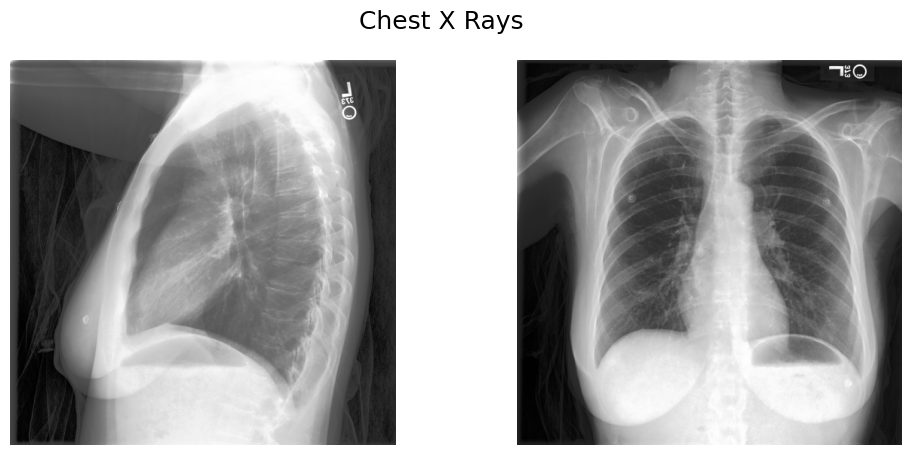

In [22]:
import cv2
import matplotlib.pyplot as plt

# Read images
img1 = cv2.imread("/content/official_data_iccv_final/files/p16/p16000035/s52654671/52d118b1-20ca3710-165a2b86-05c6b0fa-7c99aa51.jpg")
img2 = cv2.imread("/content/official_data_iccv_final/files/p16/p16000035/s52654671/8e338050-c72628f4-cf19ef85-cb13d287-5af57beb.jpg" )
# img3 = cv2.imread('/content/xray3.png')

# Convert BGR -> RGB for correct colors
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
# img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# Plot images side by side
plt.figure(figsize=(12,5))
plt.suptitle("Chest X Rays", fontsize=18)

plt.subplot(1,2,1)
plt.imshow(img1)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.axis('off')

# plt.subplot(1,3,3)
# plt.imshow(img3)
# plt.axis('off')

plt.show()

In [23]:
report = generate_single_report(
    model     = model,
    tokenizer = tokenizer,
    image_paths = ["/content/official_data_iccv_final/files/p16/p16000035/s52654671/52d118b1-20ca3710-165a2b86-05c6b0fa-7c99aa51.jpg",
                   "/content/official_data_iccv_final/files/p16/p16000035/s52654671/8e338050-c72628f4-cf19ef85-cb13d287-5af57beb.jpg" ],
    device = DEVICE,
)


print(report)


Findings: Impression: As compared to the previous radiograph, no relevant change is seen. Normal lung volumes. Normal size of the cardiac silhouette. Normal hilar and mediastinal structures. No pleural effusions. No pneumonia, no pulmonary edema. Results: Impressions: There are no relevant changes compared to previous X-ray. Normal pulmonary volume. Normal height of the heart Silhouettes. Normal Hilar and Mediastinal structures. Neither pleural effusions nor pulmonary oedema. No pneumonia. no lung oedema... No pulmonary inflammation. no pneumonia. No lung inflammation.No pulmonary oedema, no pneumonia.No pneumonia.. Impression.. Compared to previous radiographs, there are no significant changes. Normal lungs volume


In [24]:
import textwrap
wrapped_text = textwrap.fill(report, width=190)

print(wrapped_text)

Findings: Impression: As compared to the previous radiograph, no relevant change is seen. Normal lung volumes. Normal size of the cardiac silhouette. Normal hilar and mediastinal structures.
No pleural effusions. No pneumonia, no pulmonary edema. Results: Impressions: There are no relevant changes compared to previous X-ray. Normal pulmonary volume. Normal height of the heart
Silhouettes. Normal Hilar and Mediastinal structures. Neither pleural effusions nor pulmonary oedema. No pneumonia. no lung oedema... No pulmonary inflammation. no pneumonia. No lung
inflammation.No pulmonary oedema, no pneumonia.No pneumonia.. Impression.. Compared to previous radiographs, there are no significant changes. Normal lungs volume


In [25]:
# Multiple questions on same X-ray study
questions = [
    "Is there any pleural effusion?",
    "Is the heart size normal?",
    "Is there pneumonia?",
    "Are there any fractures?",
]

for q in questions:
    answer_question(model, tokenizer,
      ["/content/official_data_iccv_final/files/p16/p16000035/s52654671/52d118b1-20ca3710-165a2b86-05c6b0fa-7c99aa51.jpg",
       "/content/official_data_iccv_final/files/p16/p16000035/s52654671/8e338050-c72628f4-cf19ef85-cb13d287-5af57beb.jpg"],
     q, DEVICE)
    print()


Q: Is there any pleural effusion?
A: PA and lateral chest views were obtained with patient in upright position. Analysis is performed in direct comparison with the next preceding similar study of _ _ _. The heart size is within normal limits. The pulmonary vasculature is not congested. No signs of acute or chronic parenchymal infiltrates are present and the lateral and posterior pleural sinuses are free. No pneumothorax in the apical area. Skeletal structures of the thorax grossly unremarkable. Impression: Findings: PA and side views were achieved with patients in upright posture. The

Q: Is the heart size normal?
A: Heart size normal. Mediastinal and hilaric contours are normal.The lungs are clear, there is no pneumothorax or pleural effusion. Impressions: No signs of acute cardiopulmonal abnormalities.. Question of the indication of acute

Q: Is there pneumonia?
A: PA and lateral chest views were obtained with patient in upright position. Analysis is performed in direct comparison wi

In [26]:
BLEU_4=8.2125
BERTScore_F1= 0.6150
CheXbert_F1=  0.5757 #0.3371
BLEU_4_norm=BLEU_4/100.0
RadCliQ_v0 = 0.5957*BERTScore_F1 + 0.4499*CheXbert_F1 - 0.1974*BLEU_4_norm